# Morse Code Classifier: Developing a Tiny Neural Network

In this workshop, we’ll train a simple neural network to **decode Morse code signals** from "timing features", and later deploy it on a **Raspberry Pi 5**.

This notebook walks through:
1. Importing libraries
2. Preprocessing the Morse dataset
3. Building a neural network in TensorFlow
4. Training and visualizing results
5. Converting the model to TensorFlow Lite format for Raspberry Pi deployment

In [2]:
# 🧩 Import required libraries
import os
import tensorflow as tf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from tensorflow.keras.callbacks import EarlyStopping

## Step 1: Define the Morse Code Classifier Class

To keep our code clean and modular, we’ll wrap everything inside a class.

This helps us easily understand, reuse and modify the model if needed.


In [3]:
class MorseCodeClassifier:
  def __init__(self):
      """Initialize model, scaler, and label encoder."""
      self.model = None
      self.scaler = StandardScaler()
      self.label_encoder = LabelEncoder()


# Step 2: Data Preprocessing

The dataset (`morse_code_data.csv`) contains timing measurements (in microseconds) and corresponding Morse characters.

Each row looks like this:
```
timing1, timing2, signal3, signal4, letter
447872,	138585,	549335,	133193, C
```
We'll:
1. Read the CSV file
2. Separate the timing features (X) and labels (y)
3. Encode the letters into numbers for training
4. Scale the timing data so the model trains faster


In [4]:
def preprocess_data(self, data_path):
    # Read the CSV file
    df = pd.read_csv(data_path, header=None)

    # Extract features (first 4 columns) and labels (last column)
    X = df.iloc[:, :4].values
    y = df.iloc[:, 4].str.strip()  # Remove any whitespace

    # Encode string labels (e.g., A, B, C) to numbers
    y_encoded = self.label_encoder.fit_transform(y)

    # Standardize feature scales
    X_scaled = self.scaler.fit_transform(X)

    return X_scaled, y_encoded

# Add this method to the class
MorseCodeClassifier.preprocess_data = preprocess_data


# Step 3: Build the Neural Network

We’ll build a **simple feedforward neural network** with:
- Two hidden layers (16 neurons each + ReLU activation)
- Softmax output layer for multi-class classification

The last output neuron is reserved for “unclassified” Morse patterns.


In [5]:
def build_model(self, input_shape, num_classes):
    model = tf.keras.Sequential([
        tf.keras.layers.Dense(16, activation='relu', input_shape=(input_shape,)),
        tf.keras.layers.Dense(16, activation='relu'),
        tf.keras.layers.Dense(num_classes + 1, activation='softmax')  # +1 = unclassified
    ])

    model.compile(
        optimizer='adam',
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )

    self.model = model
    return model

MorseCodeClassifier.build_model = build_model


# Step 4: Train the Model

- We use **early stopping** to prevent overfitting.
- We also add a small amount of random "unclassified" data to make the model robust.
- Training and validation accuracy/loss will be plotted afterward.


In [6]:
def train(self, X, y, validation_split=0.2, epochs=50, batch_size=32, patience=5):
    # Create 10% "unclassified" random samples
    X_unclassified = np.random.randn(len(X) // 10, X.shape[1])
    y_unclassified = np.full(len(X_unclassified), len(np.unique(y)))

    # Combine classified + unclassified data
    X_combined = np.vstack([X, X_unclassified])
    y_combined = np.concatenate([y, y_unclassified])

    # Split into train and validation sets
    X_train, X_val, y_train, y_val = train_test_split(
        X_combined, y_combined, test_size=validation_split, random_state=42
    )

    # Stop training when validation loss stops improving
    early_stopping = EarlyStopping(
        monitor='val_loss',
        patience=patience,
        restore_best_weights=True
    )

    # Train model
    self.history = self.model.fit(
        X_train, y_train,
        validation_data=(X_val, y_val),
        epochs=epochs,
        batch_size=batch_size,
        callbacks=[early_stopping],
        verbose=1
    )

    self.plot_training_history()
    return self.history

MorseCodeClassifier.train = train

# Step 5: Plot Training History

We want to visualize how the model performed over time.
- Accuracy plot shows how well the model learned.
- Loss plot shows how well it minimized prediction error.


In [7]:

def plot_training_history(self):
    """Plot accuracy and loss curves."""
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

    ax1.plot(self.history.history['accuracy'], label='Training Accuracy')
    ax1.plot(self.history.history['val_accuracy'], label='Validation Accuracy')
    ax1.set_title('Model Accuracy')
    ax1.set_xlabel('Epoch')
    ax1.set_ylabel('Accuracy')
    ax1.legend()
    ax1.grid(True)

    ax2.plot(self.history.history['loss'], label='Training Loss')
    ax2.plot(self.history.history['val_loss'], label='Validation Loss')
    ax2.set_title('Model Loss')
    ax2.set_xlabel('Epoch')
    ax2.set_ylabel('Loss')
    ax2.legend()
    ax2.grid(True)

    plt.tight_layout()
    plt.show()

MorseCodeClassifier.plot_training_history = plot_training_history


# Step 6: Make Predictions

Once trained, we can feed in new Morse timing data and get the predicted letter.

The model scales the input, makes a prediction, and converts the output index back to a letter.


In [8]:
def predict(self, timing_data):
    """Predict Morse code characters from timing data."""
    if len(timing_data.shape) == 1:
        timing_data = timing_data.reshape(1, -1)

    timing_data_scaled = self.scaler.transform(timing_data)
    predictions = self.model.predict(timing_data_scaled)

    predicted_classes = np.argmax(predictions, axis=1)

    results = []
    for pred_class in predicted_classes:
        if pred_class == len(self.label_encoder.classes_):
            results.append('U')  # Unclassified
        else:
            results.append(self.label_encoder.inverse_transform([pred_class])[0])

    return results, predictions

MorseCodeClassifier.predict = predict


# Step 7: Run Everything!

Let’s bring it all together:
1. Initialize the classifier
2. Preprocess the dataset
3. Build the model
4. Train it and visualize performance


Epoch 1/200


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


13/13 ━━━━━━━━━━━━━━━━━━━━ 2s 26ms/step - accuracy: 0.0953 - loss: 2.3910 - val_accuracy: 0.1313 - val_loss: 2.3613
Epoch 2/200
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.1051 - loss: 2.3523 - val_accuracy: 0.1616 - val_loss: 2.3174
Epoch 3/200
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.1444 - loss: 2.3135 - val_accuracy: 0.2020 - val_loss: 2.2721
Epoch 4/200
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.2240 - loss: 2.2472 - val_accuracy: 0.3434 - val_loss: 2.2246
Epoch 5/200
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.3082 - loss: 2.2245 - val_accuracy: 0.3333 - val_loss: 2.1745
Epoch 6/200
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.3716 - loss: 2.1508 - val_accuracy: 0.3535 - val_loss: 2.1201
Epoch 7/200
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.4177 - loss: 2.0713 - val_accuracy: 0.3636 - val_loss: 2.0633
Epoch 8/200
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.4179 - loss: 2.0312 - val_accuracy: 0.3636 - val_loss: 2

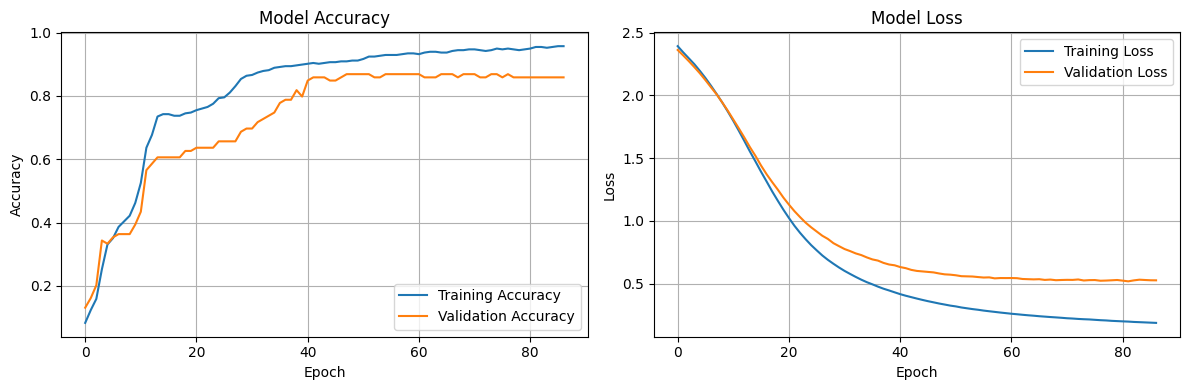

In [10]:
# Initialize classifier
classifier = MorseCodeClassifier()

# Load and preprocess data
X, y = classifier.preprocess_data('morse_code_data.csv')

# Build model
input_shape = X.shape[1]
num_classes = len(np.unique(y))
classifier.build_model(input_shape, num_classes)

# Train model
history = classifier.train(X, y, epochs=200, patience=5)

## Step 8: Convert Model to TFLite for Raspberry Pi 5 Deployment

In [12]:
def convert_to_tflite(classifier, output_dir="./model_export"):
    """
    Convert the trained TensorFlow/Keras model to TFLite format.

    Works with models built using tf.keras (like your MorseCodeClassifier).
    """
    # Create output directory
    os.makedirs(output_dir, exist_ok=True)

    print("=" * 60)
    print("  TFLite Model Conversion for Raspberry Pi 5")
    print("=" * 60)
    print()

    # Verify model exists
    if not hasattr(classifier, 'model') or classifier.model is None:
        raise ValueError("Classifier must have a trained model. Run training first!")

    print(f"Model type: {type(classifier.model).__name__}")
    print(f"Is Keras model: {isinstance(classifier.model, tf.keras.Model)}")
    print()

    # -------------------------------------------------------------------------
    # Step 1: Convert TensorFlow/Keras model to TFLite
    # -------------------------------------------------------------------------
    print("Step 1: Converting TensorFlow/Keras model to TFLite...")

    try:
        # This works for models built with tf.keras.Sequential
        converter = tf.lite.TFLiteConverter.from_keras_model(classifier.model)
        print("Using from_keras_model() converter")
    except Exception as e:
        print(f"from_keras_model() failed: {e}")
        print("Trying alternative: Save to SavedModel first...")

        # Fallback: Save to SavedModel format, then convert
        saved_model_dir = os.path.join(output_dir, "saved_model_temp")
        classifier.model.save(saved_model_dir)
        converter = tf.lite.TFLiteConverter.from_saved_model(saved_model_dir)
        print("Using from_saved_model() converter")

    # Apply optimizations for Raspberry Pi
    converter.optimizations = [tf.lite.Optimize.DEFAULT]

    # Convert the model
    print("   Converting model (this may take a moment)...")
    tflite_model = converter.convert()
    print("Conversion successful!")

    # Save the TFLite model
    model_path = os.path.join(output_dir, "morse_classifier.tflite")
    with open(model_path, 'wb') as f:
        f.write(tflite_model)

    model_size_kb = len(tflite_model) / 1024
    print(f"Model saved: {model_path}")
    print(f"Size: {model_size_kb:.2f} KB")
    print()

    # -------------------------------------------------------------------------
    # Step 2: Export normalization parameters
    # -------------------------------------------------------------------------
    print("Step 2: Exporting normalization parameters...")

    # Extract mean and scale from the StandardScaler
    mean = classifier.scaler.mean_.astype(np.float32)
    scale = classifier.scaler.scale_.astype(np.float32)

    config_path = os.path.join(output_dir, "normalization_config.npz")
    np.savez(config_path, mean=mean, scale=scale)

    print(f" Config saved: {config_path}")
    print(f" Mean values:  {mean}")
    print(f" Scale values: {scale}")
    print()

    # -------------------------------------------------------------------------
    # Step 3: Verify the converted model
    # -------------------------------------------------------------------------
    print("Step 3: Verifying TFLite model...")

    # Load and test the converted model
    interpreter = tf.lite.Interpreter(model_path=model_path)
    interpreter.allocate_tensors()

    input_details = interpreter.get_input_details()
    output_details = interpreter.get_output_details()

    print(f"   Input shape:  {input_details[0]['shape']}")
    print(f"   Input dtype:  {input_details[0]['dtype']}")
    print(f"   Output shape: {output_details[0]['shape']}")
    print(f"   Output dtype: {output_details[0]['dtype']}")
    print()

    # -------------------------------------------------------------------------
    # Summary
    # -------------------------------------------------------------------------
    print("=" * 60)
    print("Conversion Complete!")
    print("=" * 60)
    print()
    print(" Generated files:")
    print(f"   {model_path}")
    print(f"   {config_path}")
    print()


    return model_path, config_path


# =============================================================================
# 🚀 Run the conversion
# =============================================================================
# Make sure 'classifier' is your trained MorseCodeClassifier instance
# (It should exist from the training cells above)

try:
    model_path, config_path = convert_to_tflite(classifier)
except NameError:
    print("   Error: 'classifier' not found!")
    print("   Please run the training cells first to create the classifier.")
except Exception as e:
    print(f"  Error during conversion: {e}")
    import traceback
    traceback.print_exc()

  TFLite Model Conversion for Raspberry Pi 5

Model type: Sequential
Is Keras model: True

Step 1: Converting TensorFlow/Keras model to TFLite...
Using from_keras_model() converter
   Converting model (this may take a moment)...
Saved artifact at '/tmp/tmpgzpn_i3x'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 4), dtype=tf.float32, name='keras_tensor')
Output Type:
  TensorSpec(shape=(None, 11), dtype=tf.float32, name=None)
Captures:
  138355751959440: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138355751959632: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138355746948688: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138355746949072: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138355746948496: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138355746947536: TensorSpec(shape=(), dtype=tf.resource, name=None)
Conversion successful!
Model saved: ./model_export/morse_classifier.tflite
S

/usr/local/lib/python3.12/dist-packages/tensorflow/lite/python/interpreter.py:457: UserWarning:     Warning: tf.lite.Interpreter is deprecated and is scheduled for deletion in
    TF 2.20. Please use the LiteRT interpreter from the ai_edge_litert package.
    See the [migration guide](https://ai.google.dev/edge/litert/migration)
    for details.
    
  warnings.warn(_INTERPRETER_DELETION_WARNING)
